# 06 — Probabilistic Forecast Generation

## Purpose
This notebook generates probabilistic forecast trajectories using each forecasting model and innovation model combination.

## Outputs
- Forecast path simulations
- Prediction intervals
- Forecast comparison figures
- Forecast evaluation summaries

## Future Work
- Improve RNN residual-injection forecasts
- Extend forecasting experiments to real-world datasets

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.utils.seeds import set_seed
from src.utils.device import get_device

from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import (
    load_array_npz,
    save_array_npz,
    save_table,
    save_json,
    save_current_figure,
)

set_seed(123)

config = ExperimentConfig()
device = get_device()

dgp_names = config.dgp_names

forecast_models = [
    "VAR",
    "RNN",
]

innovation_model_names = [
    "gaussian",
    "bootstrap",
    "student_t",
    "diffusion",
]

lags = config.lags
n_train = config.n_train
horizon = config.horizon
n_paths = config.n_paths

rnn_context_length = 40
rnn_prediction_length = horizon
rnn_hidden_dim = 64
rnn_num_layers = 1
rnn_dropout = 0.0
rnn_batch_size = 32
rnn_epochs = 100
rnn_lr = 1e-3
rnn_device = device

dirs = result_dirs(
    "06_forecasts",
    test=False,
)

simulated_dir = ROOT / "data" / "simulated"

datasets = {}

for dgp_name in dgp_names:
    dgp_data = load_array_npz(
        simulated_dir / f"{dgp_name}_var_dgp.npz"
    )

    y = dgp_data["y"]

    y_train = y[:n_train]
    y_test = y[n_train:n_train + horizon]

    datasets[dgp_name] = {
        "y": y,
        "y_train": y_train,
        "y_test": y_test,
    }

    print(
        dgp_name,
        "train:",
        y_train.shape,
        "test:",
        y_test.shape,
    )

gaussian train: (300, 3) test: (40, 3)
student_t train: (300, 3) test: (40, 3)
mixture train: (300, 3) test: (40, 3)
heteroskedastic train: (300, 3) test: (40, 3)


In [2]:
from src.api.modeling import (
    fit_forecasting_models,
)

fitted_models = fit_forecasting_models(
    datasets=datasets,
    forecast_models=forecast_models,
    lags=lags,
    rnn_context_length=rnn_context_length,
    rnn_prediction_length=rnn_prediction_length,
    rnn_hidden_dim=rnn_hidden_dim,
    rnn_num_layers=rnn_num_layers,
    rnn_dropout=rnn_dropout,
    rnn_batch_size=rnn_batch_size,
    rnn_epochs=rnn_epochs,
    rnn_lr=rnn_lr,
    rnn_device=rnn_device,
    output_dir=dirs["models"],
)

VAR gaussian fit complete
VAR student_t fit complete
VAR mixture fit complete
VAR heteroskedastic fit complete
RNN gaussian fit complete
RNN student_t fit complete
RNN mixture fit complete
RNN heteroskedastic fit complete


In [3]:
from src.api.forecasts import (
    prepare_innovation_paths_for_forecasting,
)

residual_dir = ROOT / "results" / "residuals" / "03_residuals"
diffusion_dir = ROOT / "results" / "innovations" / "05_diffusion"

innovation_models, innovation_paths = prepare_innovation_paths_for_forecasting(
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    n_paths=n_paths,
    horizon=horizon,
    seed=config.seed,
    student_t_df=config.student_t_df,
    residual_dir=residual_dir,
    diffusion_dir=diffusion_dir,
)

VAR gaussian gaussian (250, 40, 3)
VAR gaussian bootstrap (250, 40, 3)
VAR gaussian student_t (250, 40, 3)
VAR gaussian diffusion (250, 40, 3)
VAR student_t gaussian (250, 40, 3)
VAR student_t bootstrap (250, 40, 3)
VAR student_t student_t (250, 40, 3)
VAR student_t diffusion (250, 40, 3)
VAR mixture gaussian (250, 40, 3)
VAR mixture bootstrap (250, 40, 3)
VAR mixture student_t (250, 40, 3)
VAR mixture diffusion (250, 40, 3)
VAR heteroskedastic gaussian (250, 40, 3)
VAR heteroskedastic bootstrap (250, 40, 3)
VAR heteroskedastic student_t (250, 40, 3)
VAR heteroskedastic diffusion (250, 40, 3)
RNN gaussian gaussian (250, 40, 3)
RNN gaussian bootstrap (250, 40, 3)
RNN gaussian student_t (250, 40, 3)
RNN gaussian diffusion (250, 40, 3)
RNN student_t gaussian (250, 40, 3)
RNN student_t bootstrap (250, 40, 3)
RNN student_t student_t (250, 40, 3)
RNN student_t diffusion (250, 40, 3)
RNN mixture gaussian (250, 40, 3)
RNN mixture bootstrap (250, 40, 3)
RNN mixture student_t (250, 40, 3)
RNN mi

/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: divide by zero encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: overflow encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: invalid value encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: divide by zero encountered in matmul
  z = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: overflow encountered in matmul
  z = rng.multivariate_normal(
/

In [4]:
def generate_rnn_residual_injection_forecasts(
    fitted_model,
    y_history,
    residual_shocks,
):
    """
    RNN mean forecast + sampled residual shocks.

    residual_shocks:
        Shape (n_paths, horizon, k)
    """
    from src.deep_ar.forecast import rnn_predict_distribution

    context_length = fitted_model["context_length"]

    context = y_history[-context_length:]

    mean, scale = rnn_predict_distribution(
        model=fitted_model["model"],
        context=context,
        device=fitted_model.get("device", "cpu"),
    )

    forecast_paths = mean[None, :, :] + residual_shocks

    return {
        "forecast_paths": forecast_paths,
        "innovation_paths": residual_shocks,
        "predictive_mean": mean,
        "predictive_scale": scale,
    }

## Recursive Forecast Generation

Each innovation path is propagated through the fitted VAR model.

For each DGP and innovation model, the forecast recursion is:

$y_{t+h}^{(m)} = c + A y_{t+h-1}^{(m)} + \varepsilon_{t+h}^{(m)}$

where $\varepsilon_{t+h}^{(m)}$ is sampled from one of the fitted innovation models.

In [5]:
from src.api.forecasts import (
    generate_forecast_experiments,
)

forecast_store = generate_forecast_experiments(
    datasets=datasets,
    fitted_models=fitted_models,
    innovation_paths=innovation_paths,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
    lags=lags,
    horizon=horizon,
    n_paths=n_paths,
    output_dir=dirs["forecasts"],
)

VAR gaussian gaussian (250, 40, 3)
VAR gaussian bootstrap (250, 40, 3)
VAR gaussian student_t (250, 40, 3)
VAR gaussian diffusion (250, 40, 3)
VAR student_t gaussian (250, 40, 3)
VAR student_t bootstrap (250, 40, 3)
VAR student_t student_t (250, 40, 3)
VAR student_t diffusion (250, 40, 3)
VAR mixture gaussian (250, 40, 3)
VAR mixture bootstrap (250, 40, 3)
VAR mixture student_t (250, 40, 3)
VAR mixture diffusion (250, 40, 3)
VAR heteroskedastic gaussian (250, 40, 3)
VAR heteroskedastic bootstrap (250, 40, 3)
VAR heteroskedastic student_t (250, 40, 3)
VAR heteroskedastic diffusion (250, 40, 3)
RNN gaussian gaussian (250, 40, 3)
RNN gaussian bootstrap (250, 40, 3)
RNN gaussian student_t (250, 40, 3)
RNN gaussian diffusion (250, 40, 3)
RNN student_t gaussian (250, 40, 3)
RNN student_t bootstrap (250, 40, 3)
RNN student_t student_t (250, 40, 3)
RNN student_t diffusion (250, 40, 3)
RNN mixture gaussian (250, 40, 3)
RNN mixture bootstrap (250, 40, 3)
RNN mixture student_t (250, 40, 3)
RNN mi

In [6]:
from src.api.forecasts import (
    forecast_summary_table,
)

forecast_summary_df = forecast_summary_table(
    forecast_store=forecast_store,
    datasets=datasets,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
    interval=(0.05, 0.95),
    nominal_levels=(0.5, 0.8, 0.9),
)

save_table(
    forecast_summary_df,
    dirs["tables"] / "forecast_summary.csv",
)

forecast_summary_df

,dgp,forecast_model,innovation_model,avg_coverage,avg_width,energy_score,crps,interval_score,ece,pit_deviation,coverage_1,width_1,coverage_2,width_2,coverage_3,width_3
0,gaussian,VAR,gaussian,0.916667,3.670213,1.274063,0.637698,4.961294,0.019444,0.030000,0.875,3.935322,0.975,3.522003,0.900,3.553314
1,gaussian,VAR,bootstrap,0.883333,3.652746,1.286276,0.641768,5.039560,0.022222,0.033333,0.875,3.918968,0.975,3.524737,0.800,3.514531
2,gaussian,VAR,student_t,0.900000,3.570950,1.277481,0.639342,4.950210,0.016667,0.031667,0.875,3.882369,0.975,3.394392,0.850,3.436089
3,gaussian,VAR,diffusion,0.883333,3.699166,1.312506,0.655594,5.129345,0.013889,0.036667,0.875,4.062126,0.925,3.422134,0.850,3.613238
4,student_t,VAR,gaussian,0.758333,5.037937,2.859699,1.444045,15.814952,0.091667,0.020000,0.700,5.478175,0.800,5.086887,0.775,4.548750
5,student_t,VAR,bootstrap,0.750000,4.833426,2.864665,1.449353,15.987955,0.141667,0.036667,0.725,5.417761,0.800,4.759202,0.725,4.323314
6,student_t,VAR,student_t,0.775000,4.855081,2.863670,1.447021,16.221903,0.116667,0.033333,0.725,5.340080,0.800,4.854481,0.800,4.370683
7,student_t,VAR,diffusion,0.775000,4.987864,2.894360,1.457268,16.241979,0.119444,0.030000,0.725,5.521223,0.800,4.901636,0.800,4.540734
8,mixture,VAR,gaussian,0.866667,5.190262,2.047262,1.008706,9.283644,0.033333,0.026667,0.875,5.490154,0.800,5.102022,0.925,4.978609
9,mixture,VAR,bootstrap,0.858333,4.911980,2.026307,0.996754,9.300781,0.038889,0.031667,0.875,5.400206,0.850,4.796475,0.850,4.539257


Saved: heteroskedastic_forecast_grid_var_rnn.png


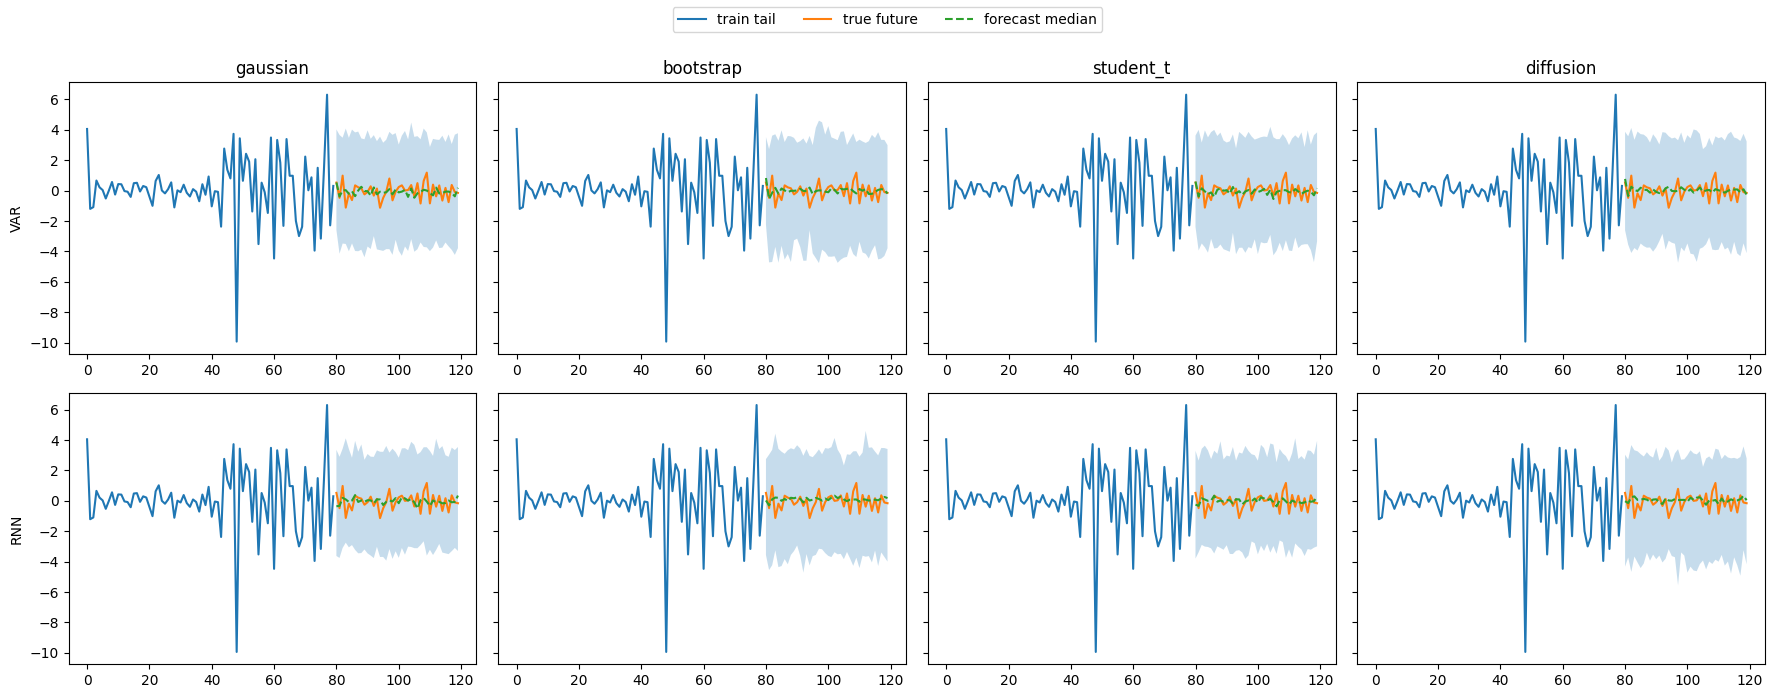

In [7]:
from src.plots.forecasts import plot_forecast_grid_for_dgp

plot_forecast_grid_for_dgp(
    datasets=datasets,
    forecast_store=forecast_store,
    forecast_models=forecast_models,
    innovation_model_names=innovation_model_names,
    dgp_name="heteroskedastic",
    horizon=horizon,
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "heteroskedastic_forecast_grid_var_rnn.png"
)

print("Saved: heteroskedastic_forecast_grid_var_rnn.png")

In [8]:
from src.api.forecasts import (
    forecast_interval_width_table,
)

width_df = forecast_interval_width_table(
    forecast_store=forecast_store,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
)

save_table(
    width_df,
    dirs["tables"] / "forecast_interval_widths.csv",
)

width_df

,forecast_model,dgp,innovation_model,avg_width,width_1,width_2,width_3
0,VAR,gaussian,gaussian,3.670213,3.935322,3.522003,3.553314
1,VAR,gaussian,bootstrap,3.652746,3.918968,3.524737,3.514531
2,VAR,gaussian,student_t,3.570950,3.882369,3.394392,3.436089
3,VAR,gaussian,diffusion,3.699166,4.062126,3.422134,3.613238
4,VAR,student_t,gaussian,5.037937,5.478175,5.086887,4.548750
5,VAR,student_t,bootstrap,4.833426,5.417761,4.759202,4.323314
6,VAR,student_t,student_t,4.855081,5.340080,4.854481,4.370683
7,VAR,student_t,diffusion,4.987864,5.521223,4.901636,4.540734
8,VAR,mixture,gaussian,5.190262,5.490154,5.102022,4.978609
9,VAR,mixture,bootstrap,4.911980,5.400206,4.796475,4.539257


In [9]:
width_pivot = width_df.pivot_table(
    index=["forecast_model", "dgp"],
    columns="innovation_model",
    values="avg_width",
)

width_pivot

innovation_model                bootstrap  diffusion  gaussian  student_t
forecast_model dgp                                                       
RNN            gaussian          3.092020   3.241761  3.133914   3.009000
               heteroskedastic   6.454890   6.112297  6.024438   5.735602
               mixture           4.197689   4.102738  4.585314   4.401087
               student_t         3.875231   3.783670  4.191615   4.011284
VAR            gaussian          3.652746   3.699166  3.670213   3.570950
               heteroskedastic   6.920927   6.576501  6.619488   6.403669
               mixture           4.911980   4.954449  5.190262   5.055339
               student_t         4.833426   4.987864  5.037937   4.855081

In [10]:
from src.api.forecasts import (
    best_forecast_models_table,
)

best_forecast_df = best_forecast_models_table(
    forecast_summary_df,
)

save_table(
    best_forecast_df,
    dirs["tables"] / "best_forecast_models.csv",
)

best_forecast_df

,dgp,metric,best_forecast_model,best_innovation_model,best_value
0,gaussian,energy_score,VAR,gaussian,1.274063
1,gaussian,crps,VAR,gaussian,0.637698
2,gaussian,interval_score,VAR,student_t,4.950210
3,gaussian,ece,VAR,diffusion,0.013889
4,gaussian,pit_deviation,RNN,diffusion,0.023333
5,student_t,energy_score,VAR,gaussian,2.859699
6,student_t,crps,VAR,gaussian,1.444045
7,student_t,interval_score,VAR,gaussian,15.814952
8,student_t,ece,VAR,gaussian,0.091667
9,student_t,pit_deviation,VAR,gaussian,0.020000


In [11]:
save_json(
    {
        "notebook": "06_forecasts",
        "forecast_models": forecast_models,
        "dgp_names": dgp_names,
        "innovation_model_names": innovation_model_names,
        "lags": lags,
        "n_train": n_train,
        "horizon": horizon,
        "n_paths": n_paths,
        "forecast_paths_saved": True,
    },
    dirs["logs"] / "forecast_config.json",
)

print(
    "Saved forecasts to:",
    dirs["forecasts"],
)

print(
    "Saved tables to:",
    dirs["tables"],
)

print(
    "06_forecasts completed."
)

Saved forecasts to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/forecasts/06_forecasts
Saved tables to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/tables/06_forecasts
06_forecasts completed.
